In [1]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

import numpy as np
import arc
import pairinteraction as pi
import os
from IPython.display import Latex
from scipy import constants
import pandas as pd
from pandas import DataFrame
from time import time
import sys
sys.path.append(os.path.abspath("C:\\Users\\Tommy\\OneDrive - Durham University\\level 4 Project\\Code Directory\\L4-code-directory-2"))
from my_functions import *
%matplotlib inline
np.set_printoptions(legacy='1.25')

h = constants.h
epsilon_0 = constants.epsilon_0
a_0 = constants.physical_constants['Bohr radius']
e = constants.e

In [2]:
colours = ('orange', 'green', 'red', 'blue')
orbs = ('s', 'p', 'd', 'f')

atom1 = 'Rb'
atom2 ='Cs'
l1_0, l2_0 = 0, 0
l1_1, l2_1 = 1, 1
j1_0, j2_0 = 1/2, 1/2


if atom1 == 'Rb':
    arc_atom1 = arc.Rubidium()
elif atom1 == 'Cs':
    arc_atom1 = arc.Caesium()
if atom2 == 'Rb':
    arc_atom2 = arc.Rubidium()
elif atom2 == 'Cs':
    arc_atom2 = arc.Caesium()
   
n_dif = 3
jdif = 3
ldif = 3
b=0
energy_unit = 'MHz'
channels = channels_import(atom1, l1_0, j1_0, atom2, l2_0, j2_0, l1_1, l2_1)

    n1_0  l1_0  j1_0  n2_0  l2_0  j2_0  n1_1  l1_1  j1_1  n2_1  l2_1  j2_1  \
0     45     0   0.5    47     0   0.5    45     1   1.5    46     1   1.5   
1     46     0   0.5    48     0   0.5    46     1   1.5    47     1   1.5   
2     48     0   0.5    51     0   0.5    48     1   1.5    50     1   0.5   
3     59     0   0.5    57     0   0.5    58     1   0.5    57     1   0.5   
4     61     0   0.5    65     0   0.5    61     1   0.5    64     1   0.5   
5     68     0   0.5    67     0   0.5    67     1   0.5    67     1   1.5   
6     69     0   0.5    68     0   0.5    68     1   0.5    68     1   1.5   
7     71     0   0.5    69     0   0.5    70     1   1.5    69     1   0.5   
8     72     0   0.5    70     0   0.5    71     1   1.5    70     1   0.5   
9     72     0   0.5    75     0   0.5    72     1   0.5    74     1   1.5   
10    73     0   0.5    76     0   0.5    73     1   0.5    75     1   1.5   
11    77     0   0.5    81     0   0.5    77     1   1.5    80  

In [3]:
channel = 3
c = channels.loc[channel]
# set atom properties
n1, l1, j1 = int(c['n1_0']), int(c['l1_0']), c['j1_0']
n2, l2, j2 = int(c['n2_0']), int(c['l2_0']), c['j2_0'] 

l1_1, l2_1 = int(c['l1_1']), int(c['l2_1'])

btunes = np.unique(magTune_import(atom1, n1, l1, j1, atom2, n2, l2, j2, l1_1, l2_1))

print(np.array(btunes))
theta, phi = 0, 0
dn = 3
deltamax = 1e12

n1_0, n2_0 = channels['n1_0'][channel], channels['n2_0'][channel]
n1_1, n2_1 = channels['n1_1'][channel], channels['n2_1'][channel]
j1_1, j2_1 = channels['j1_1'][channel], channels['j2_1'][channel]

m1_0s, m2_0s = np.arange(-j1_0, j1_0 + 1), np.arange(-j2_0, j2_0 + 1)
m1_i, m2_i = 0, 0


m1_1s, m2_1s = np.arange(-j1_1, j1_1 + 1), np.arange(-j2_1, j2_1 + 1)
m1_1i, m2_1i = 0, 0
print(m2_1s)
# Angular plots of C6
ns = np.arange(30,110,1)

# Defining pairinteraction kets
ket1 = pi.KetAtom(atom1, n=n1_0, l=l1_0, m=m1_0s[m1_i], j=j1_0)
ket1basis = pi.BasisAtom(atom1, n=(ket1.n,ket1.n), l=(ket1.l,ket1.l), j=(ket1.j,ket1.j))

ket2 = pi.KetAtom(atom2, n=n2_0, l=l2_0, m=m2_0s[m2_i], j=j2_0)
ket2basis = pi.BasisAtom(atom2, n=(ket2.n,ket2.n), l=(ket2.l,ket2.l), j=(ket2.j,ket2.j))

ket1_energy = ket1.get_energy(unit=energy_unit)
basis1 = pi.BasisAtom(atom1, n=(ket1.n-n_dif, ket1.n+n_dif), l=(0,ket1.l+ldif), j=(1/2,ket1.j+jdif), m=(-ket1.j-jdif, ket1.j+jdif))

ket2_energy = ket2.get_energy(unit=energy_unit)
basis2 = pi.BasisAtom(atom2, n=(ket2.n-n_dif, ket2.n+n_dif), l=(0,ket2.l+ldif), j=(1/2,ket2.j+jdif), m=(-ket2.j-jdif,ket2.j+jdif))

ket1_1, ket2_1 = pi.KetAtom(atom1, n=n1_1, l=l1_1, j=j1_1, m=m1_1s[m1_1i]), pi.KetAtom(atom2, n=n2_1, l=l2_1, j=j2_1,  m=m2_1s[m2_1i])
ket1_1basis = pi.BasisAtom(atom1, n=(ket1_1.n,ket1_1.n), l=(ket1_1.l,ket1_1.l), j=(ket1_1.j,ket1_1.j))
ket2_1basis = pi.BasisAtom(atom2, n=(ket2_1.n,ket2_1.n), l=(ket2_1.l,ket2_1.l), j=(ket2_1.j,ket2_1.j))
print(ket1_1basis.kets)

[ 4.44616645  5.94607803  8.94590118 18.26678025]
[-0.5  0.5]
[KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Rb:58,P_1/2,1/2)]


In [4]:
b_index = 1

# setting target and resonant states
ket0_tuples = []
ket1_tuples = []
for ket1 in ket1basis.kets:
    for ket2 in ket2basis.kets:
         ket0_tuples.append((ket1, ket2))
for ket1_1 in ket1_1basis.kets:
    for ket2_1 in ket2_1basis.kets:
        ket1_tuples.append((ket1_1, ket2_1))
print(len(ket0_tuples))

tuple0 = ket0_tuples[0]
tuple1 = ket1_tuples[1]

deltaM = tuple1[0].m + tuple1[1].m - tuple0[0].m - tuple0[1].m

ket_tuples = (tuple0, tuple1)

print(ket_tuples)


4
((KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2)), (KetAtom(Rb:58,P_1/2,-1/2), KetAtom(Cs:57,P_1/2,1/2)))


In [13]:
# setting target and resonant states
ket_tuples = [tuple0, tuple1]

eff_system = pi.EffectiveSystemPair(ket_tuples)

bs = np.array([0])
bs = np.append(bs, np.array(btunes))
# bs = np.linspace(0, max(btunes), 100)

thetaList = np.linspace(0, 360, 400)
rs = [5, 10, 15, 20, 25, 5000]
# rs=[10]

datapath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Data\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular\\2x2 hams\\'
if not os.path.exists(datapath):
    os.makedirs(datapath)

for tuple0 in ket0_tuples:
    for tuple1 in ket1_tuples:
        ket_tuples = [tuple0, tuple1]

        eff_system = pi.EffectiveSystemPair(ket_tuples)
        for r in rs:
            for mag in bs:
                if not os.path.exists(datapath + f'm0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, mag {np.round(mag, 3)}.csv'):
                    eff_h_dict_elements = {'theta' : thetaList, '00' : [], '01' : [], '10' : [], '11' : []}

                    eff_system.set_magnetic_field([0,0,mag], unit='G')
                    
                    eff_system.set_maximum_number_of_ket_pairs(2)
                    # for each theta
                    for theta in thetaList:
                        eff_system.set_distance(r, theta, "micrometer")
                        
                        pair_energy_pm = eff_system.get_pair_energies(energy_unit)[0]
                        H = eff_system.get_effective_hamiltonian(unit=energy_unit) - np.eye(2) * pair_energy_pm
                        
                        eff_h_dict_elements["00"].append(H[0,0])
                        eff_h_dict_elements["01"].append(H[0,1])
                        eff_h_dict_elements["10"].append(H[1,0])
                        eff_h_dict_elements["11"].append(H[1,1])

                    pd.DataFrame(eff_h_dict_elements).to_csv(datapath + f'm0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, mag {np.round(mag, 3)}.csv', index=False)
                        # print(eff_system.get_effective_hamiltonian(unit="MHz"))

In [28]:
tuple0 = ket0_tuples[0]
tuple1 = ket1_tuples[3]
bs = np.array([0])
bs = np.append(bs, np.array(btunes))

H = {f'{r}{b}' : pd.read_csv(datapath + f'm0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, mag {np.round(b, 3)}.csv') for r in rs for b in bs}
print(H)
matrix_lists = {f'{r}{b}' : [[[H[f'{r}{b}']['00'][i], H[f'{r}{b}']['01'][i]], [H[f'{r}{b}']['10'][i], H[f'{r}{b}']['11'][i]]] for i in range(len(H[f'{r}{b}']))] for r in rs for b in bs}

# matrix_lists = {f'{r}{b}' : [[[H[f'{r}{b}']['00'][i] - H[f'{5000}{b}']['00'][i], H[f'{r}{b}']['01'][i] - H[f'{5000}{b}']['01'][i]], [H[f'{r}{b}']['10'][i] - H[f'{5000}{b}']['10'][i], H[f'{r}{b}']['11'][i] - H[f'{5000}{b}']['11'][i]]] for i in range(len(H[f'{r}{b}']))] for r in rs for b in bs}

eval_list = {f'{r}{b}' : [np.linalg.eigh(matrix)[0] for matrix in matrix_lists[f'{r}{b}']] for r in rs for b in bs}
evec_list = {f'{r}{b}' : [np.linalg.eigh(matrix)[1] for matrix in matrix_lists[f'{r}{b}']] for r in rs for b in bs}


thetas = {f'{r}{b}' : H[f'{r}{b}']['theta'] for r in rs for b in bs}

{'50.0':           theta         00        01        10         11
0      0.000000  21.481178  0.000000  0.000000 -38.109096
1      0.902256  21.489164  0.007029  0.007029 -38.117082
2      1.804511  21.513081  0.028111  0.028111 -38.140999
3      2.706767  21.552797  0.063223  0.063223 -38.180715
4      3.609023  21.608095  0.112331  0.112331 -38.236013
..          ...        ...       ...       ...        ...
395  356.390977  21.608095  0.112331  0.112331 -38.236013
396  357.293233  21.552797  0.063223  0.063223 -38.180715
397  358.195489  21.513081  0.028111  0.028111 -38.140999
398  359.097744  21.489164  0.007029  0.007029 -38.117082
399  360.000000  21.481178  0.000000  0.000000 -38.109096

[400 rows x 5 columns], '54.446166453011635':           theta         00        01        10         11
0      0.000000  43.817460  0.000000  0.000000 -14.038058
1      0.902256  43.881547  0.007068  0.007068 -14.059333
2      1.804511  44.073529  0.028266  0.028266 -14.123066
3      2.706767 

0 (KetAtom(Rb:59,S_1/2,1/2), KetAtom(Cs:57,S_1/2,1/2))
1 (KetAtom(Rb:58,P_1/2,1/2), KetAtom(Cs:57,P_1/2,1/2))


C:\Users\Tommy\AppData\Local\Temp\ipykernel_15148\3393328709.py:35: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
C:\Users\Tommy\AppData\Local\Temp\ipykernel_15148\3393328709.py:20: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})


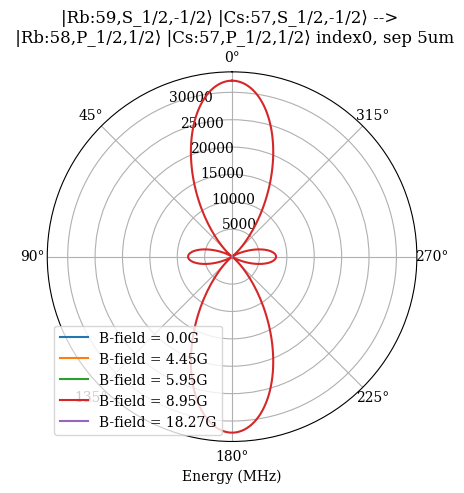

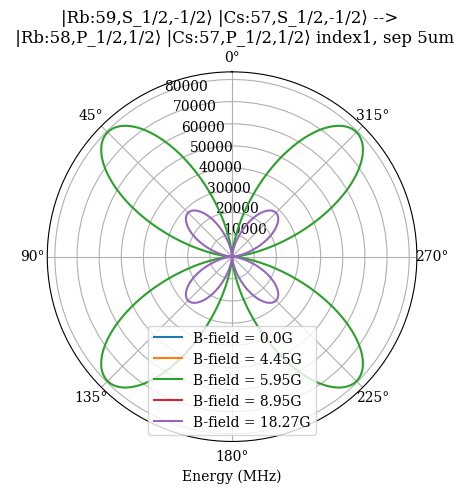

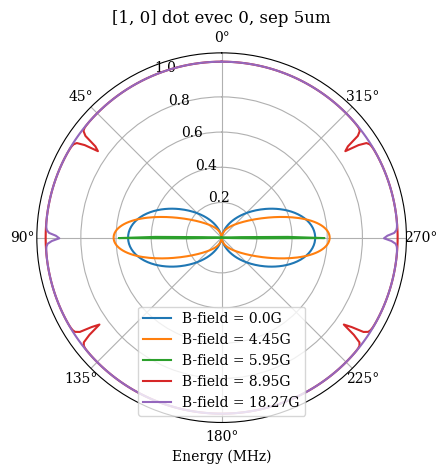

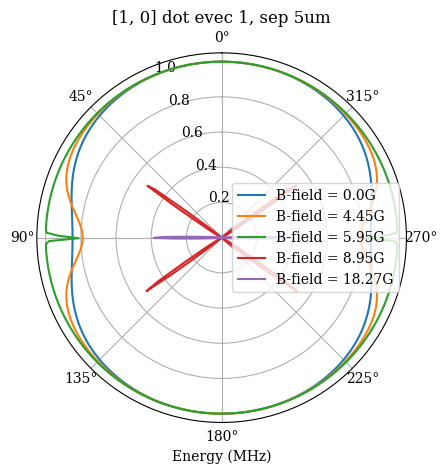

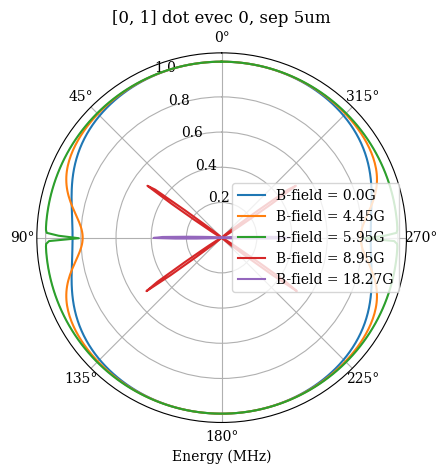

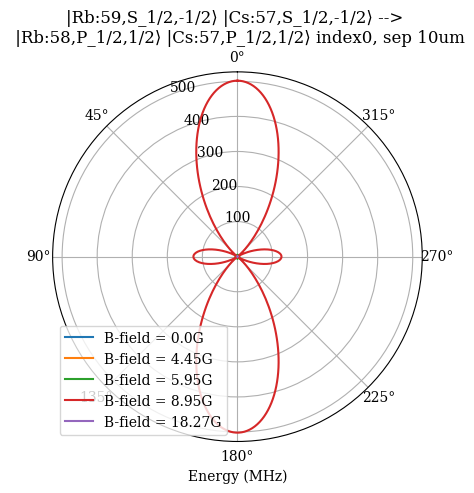

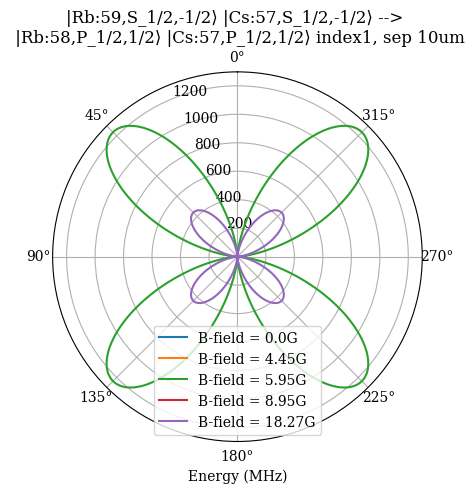

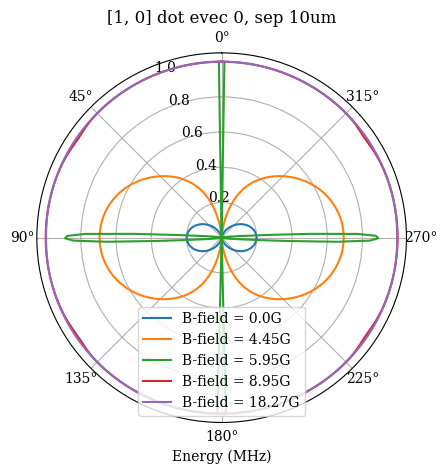

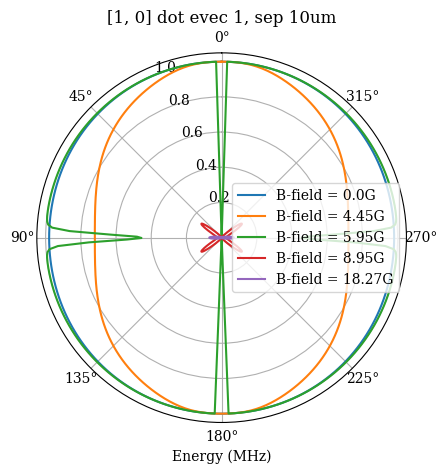

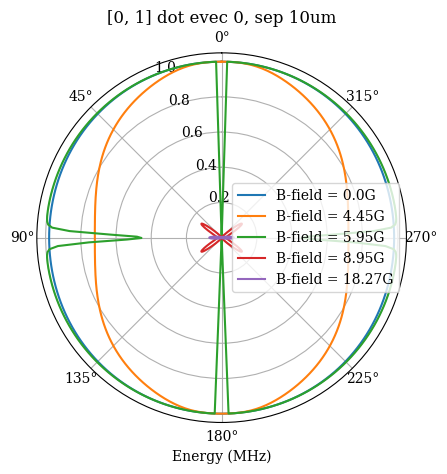

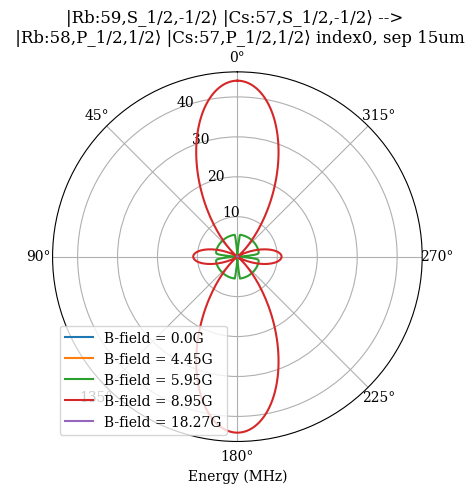

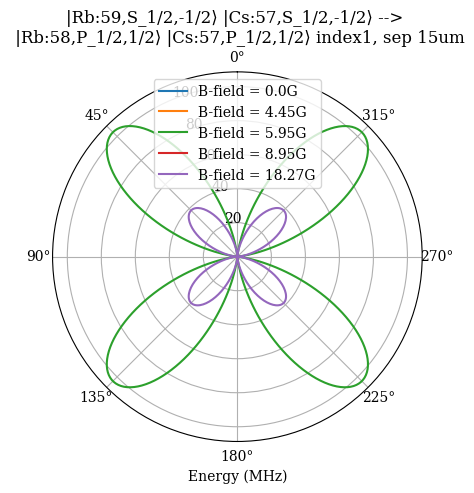

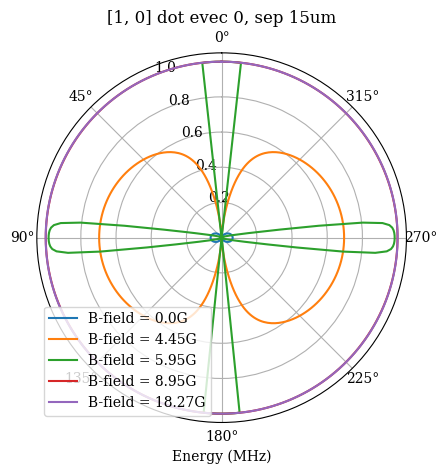

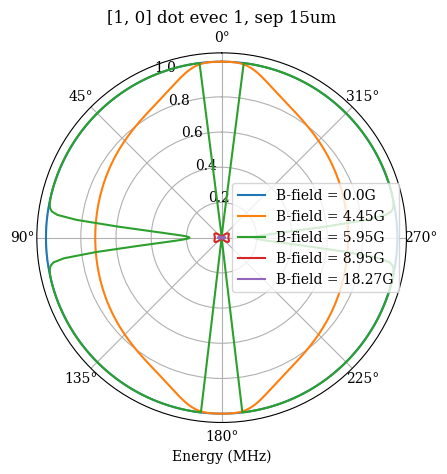

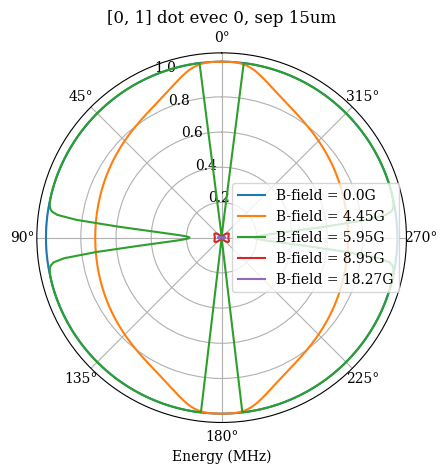

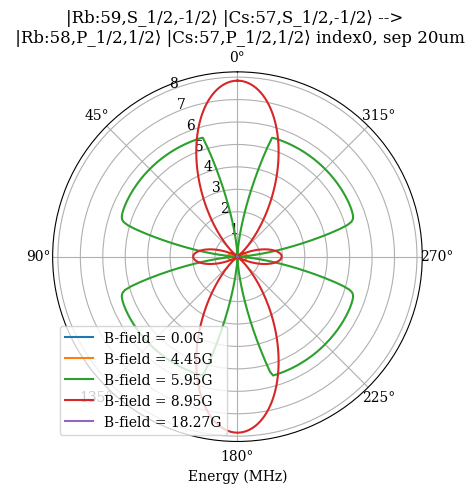

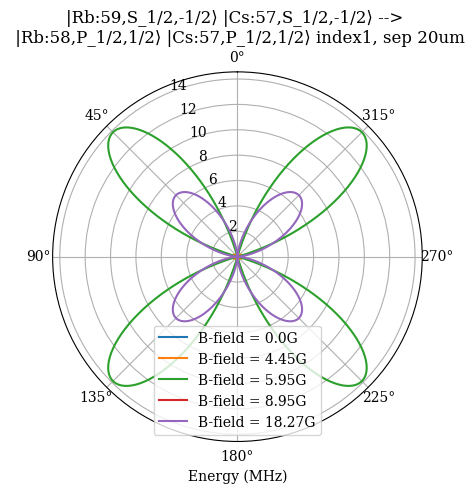

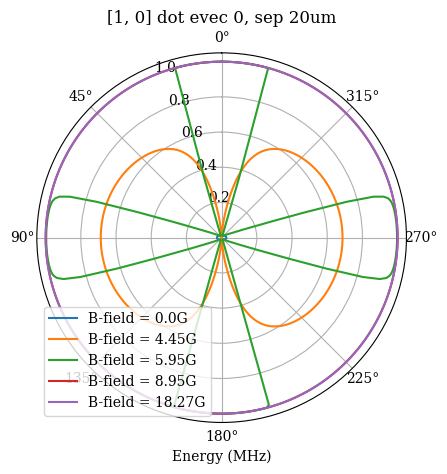

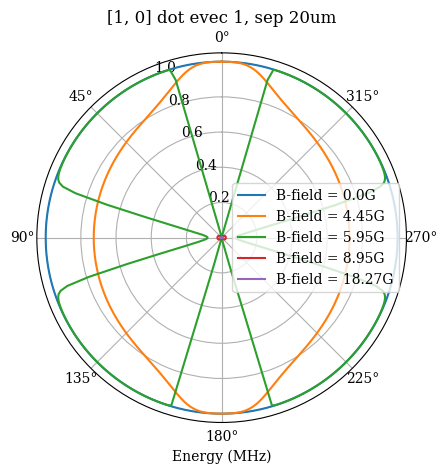

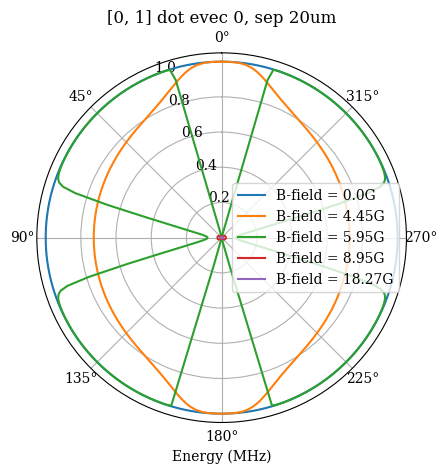

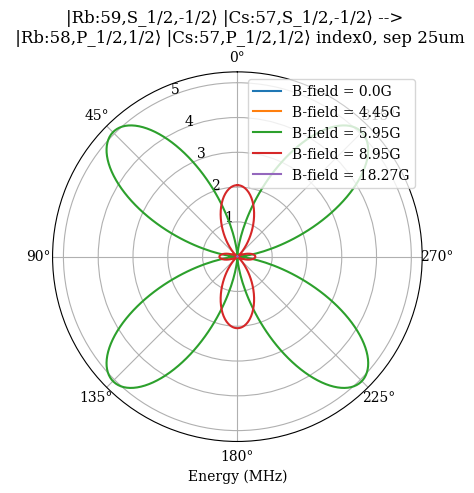

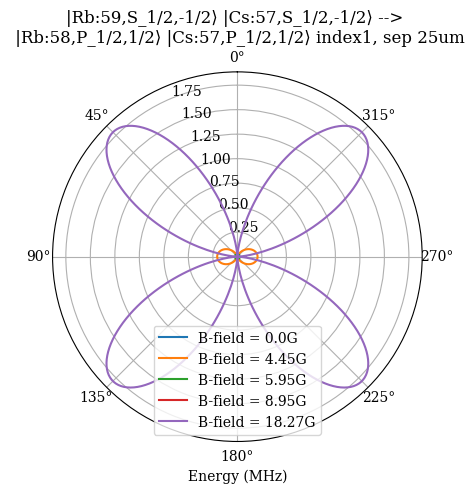

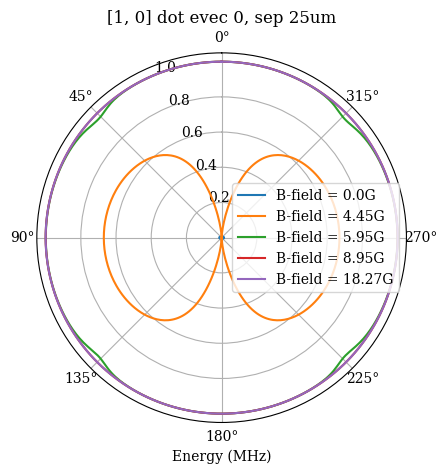

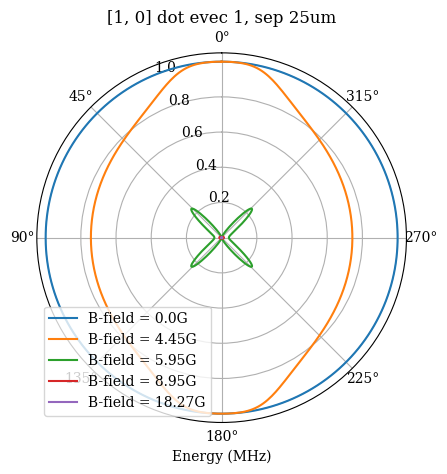

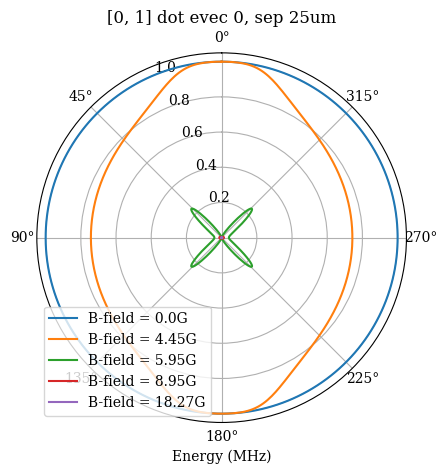

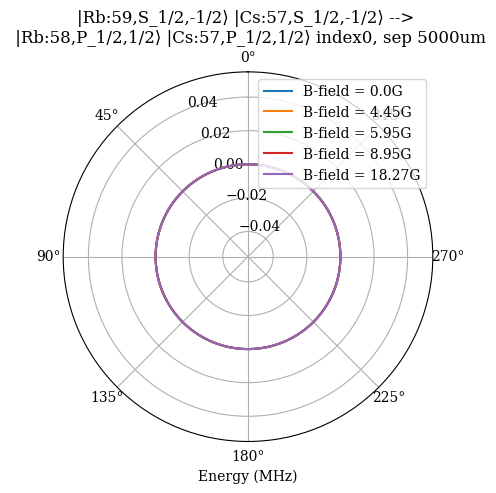

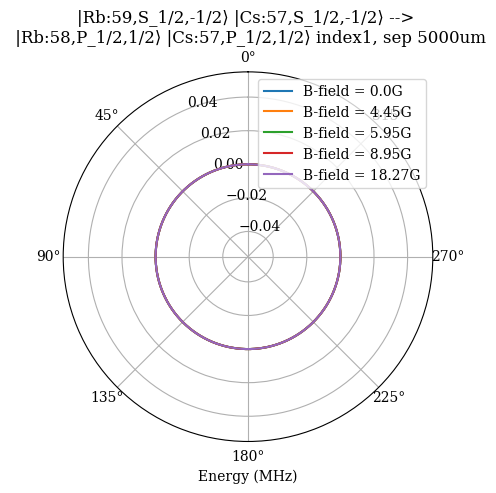

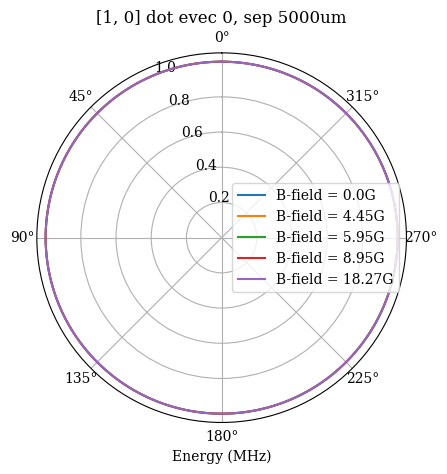

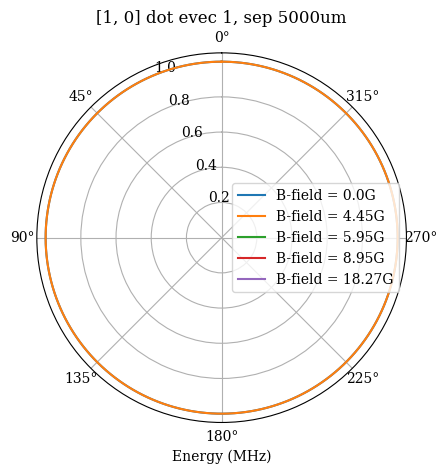

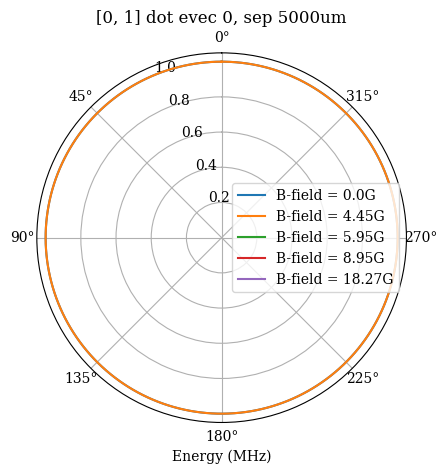

In [29]:
for i, ket in enumerate(ket_tuples):
    print(i, ket)

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular\\2x2 hams avg\\'

if not os.path.exists(figpath + 'eigenenergies\\'):
    os.makedirs(figpath + 'eigenenergies\\')
if not os.path.exists(figpath + 'overlaps\\'):
    os.makedirs(figpath + 'overlaps\\')

tups = [[1,0], [0,1]]

overlap = {f'{r}{b}' : {f'{index}{tup}' : [abs(np.dot(tup, evec[index])) for evec in evec_list[f'{r}{b}']] for index in range(2) for tup in tups} for r in rs for b in bs}
Ediag = {f'{r}{b}' : {f'{index}' : [eval[index] - eval_big[index] for eval, eval_big in zip(eval_list[f'{r}{b}'], eval_list[f'{5000}{b}'])] for index in range(2)} for r in rs for b in bs}

for r in rs:
    tup=tups[1]

    for index in range(2):
        fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
        ax.set_theta_zero_location("N")
        for b in bs:
            ax.plot(np.radians(thetas[f'{r}{b}']), abs(np.array(Ediag[f'{r}{b}'][f'{index}'])), "-", label = fr'B-field = {np.round(b,2)}G')

            
        ax.legend()
        ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} index{index}, sep {r}um')
        ax.set_xlabel(r"Energy (MHz)")
        plt.savefig(figpath + f'eigenenergies\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, e {np.round(e,1)}Vcm evec {index}.png')

    

    for tup in tups:
        for index in range(2):
            fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
            ax.set_theta_zero_location("N")
            for b in bs:         
                ax.plot(np.radians(thetas[f'{r}{b}']), overlap[f'{r}{b}'][f'{index}{tup}'], label = fr'B-field = {np.round(b,2)}G') 
            ax.legend()
            ax.set_xlabel(r"Energy (MHz)")
            ax.set_title(f'{tup} dot evec {index}, sep {r}um')
            
            plt.savefig(figpath + f'\\overlaps\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, e {np.round(e,1)}Vcm evec {index}.png')
    plt.close()

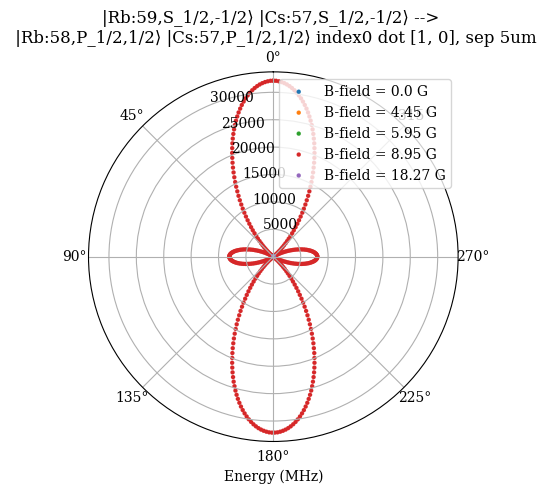

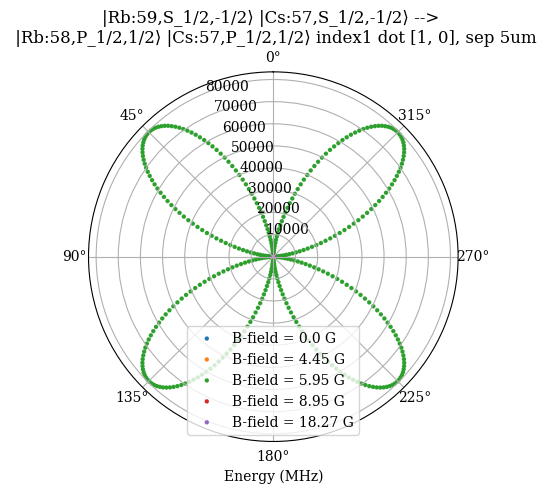

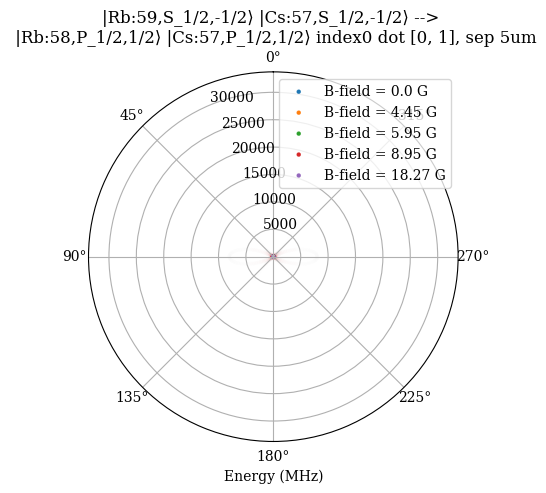

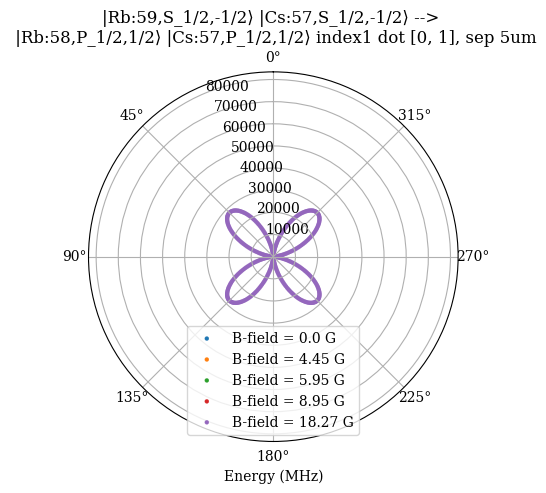

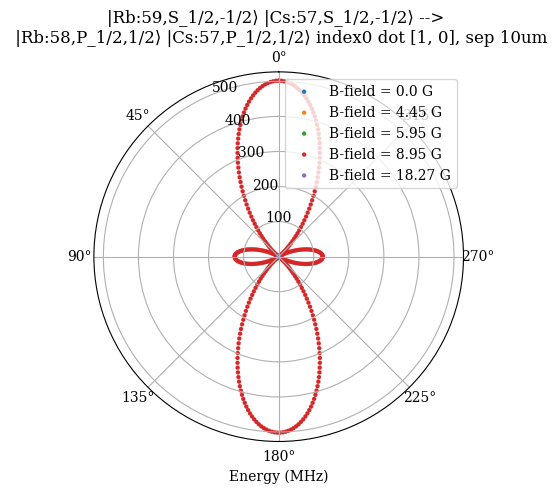

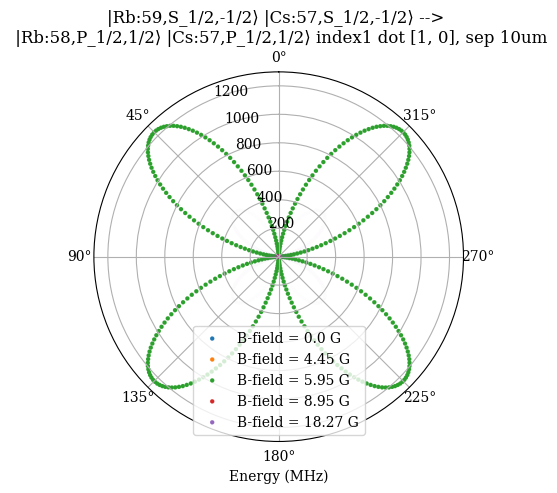

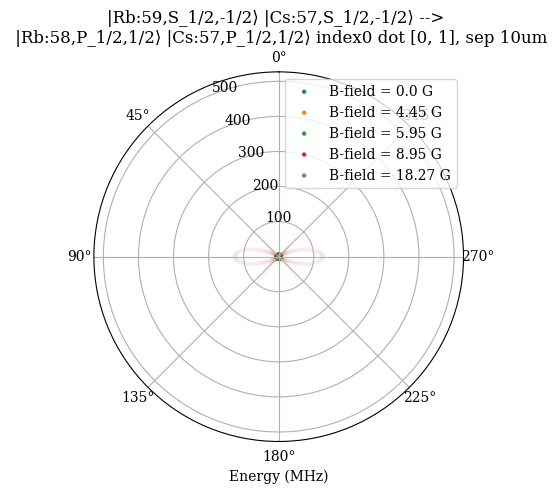

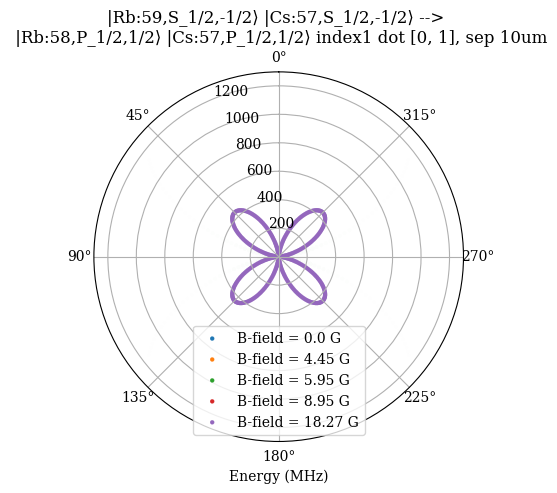

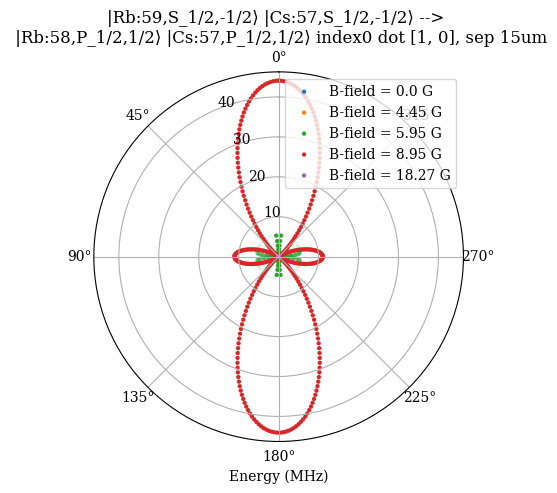

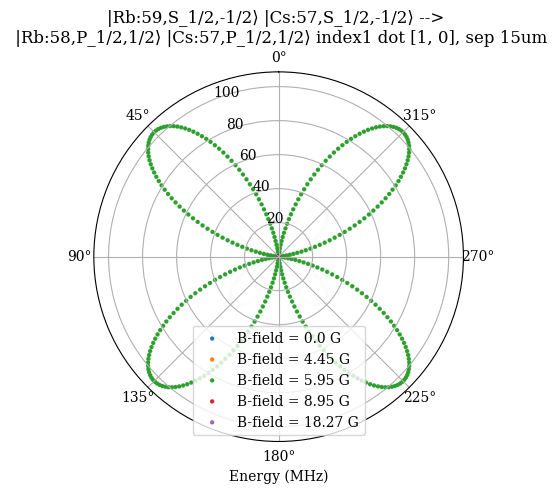

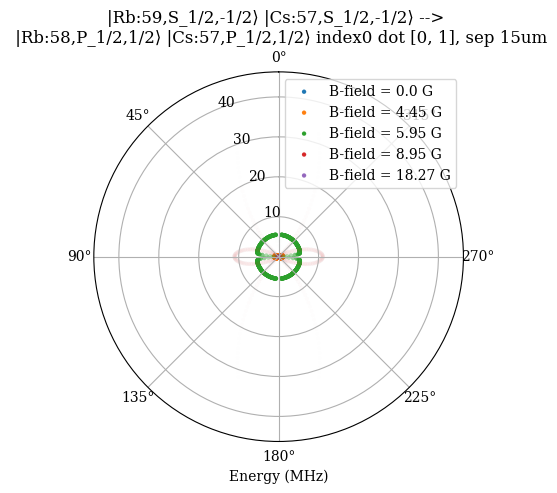

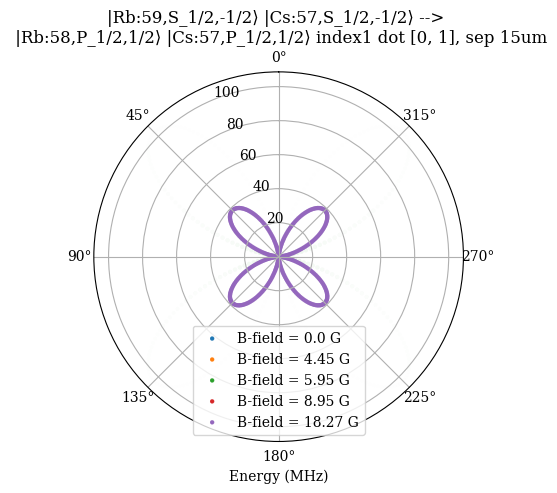

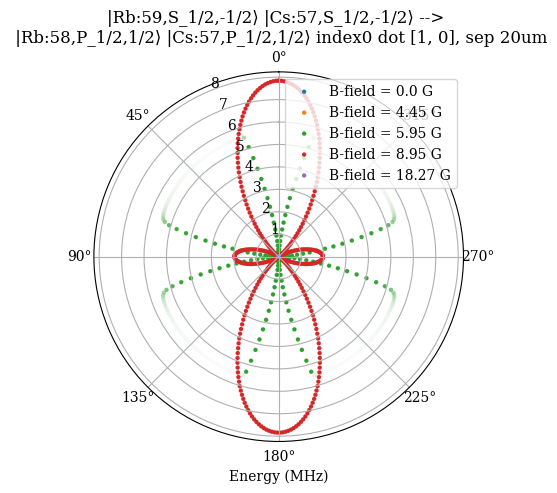

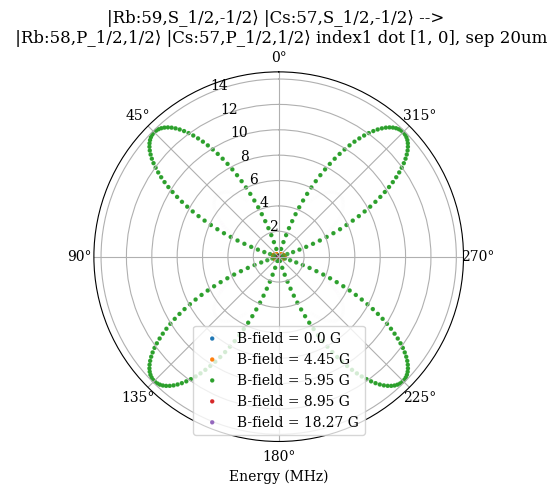

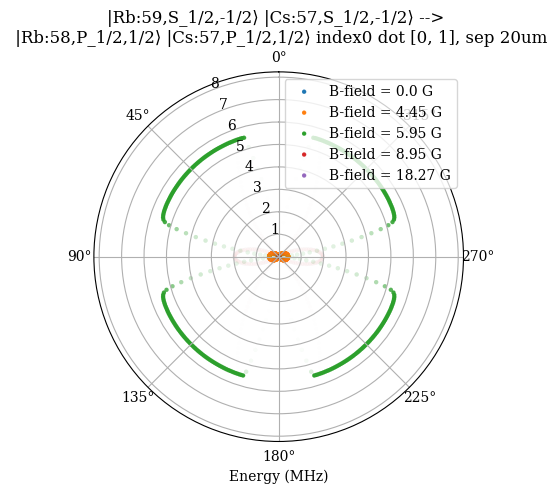

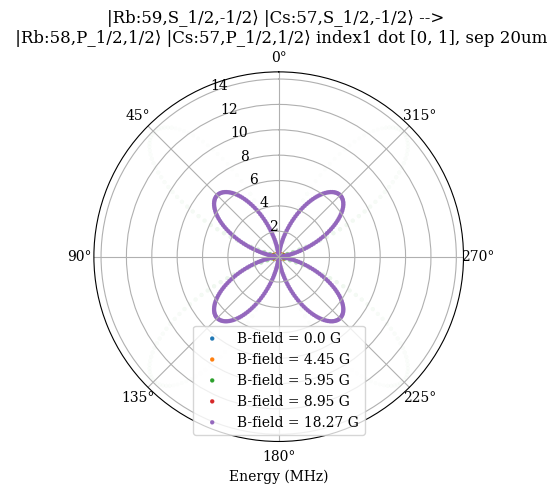

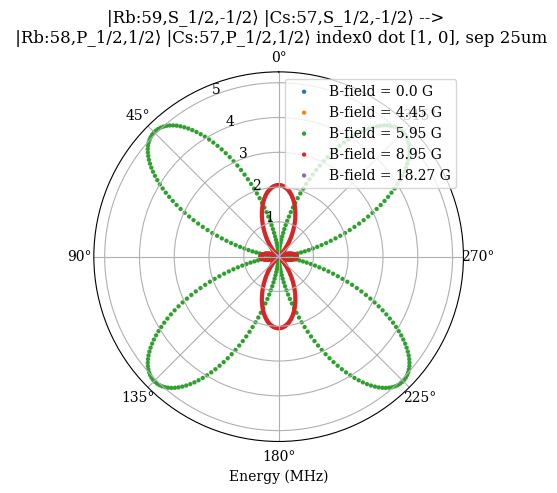

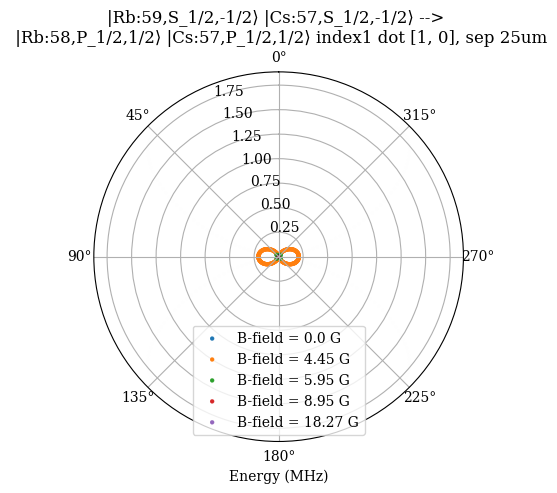

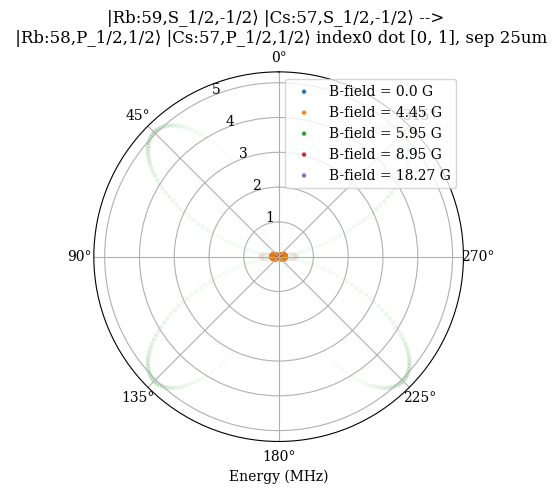

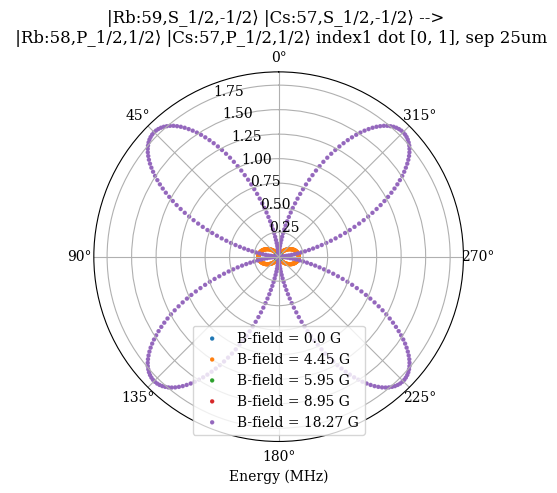

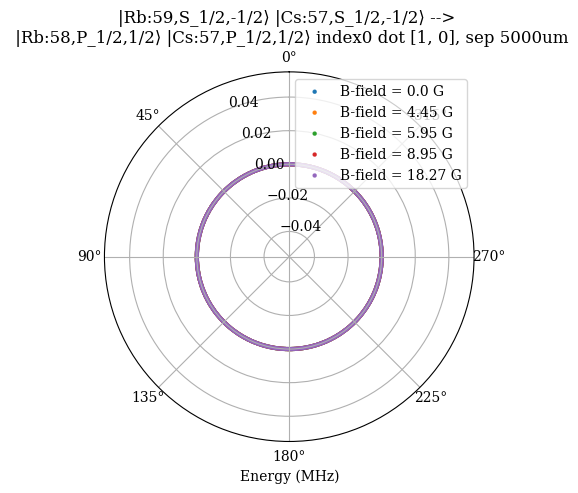

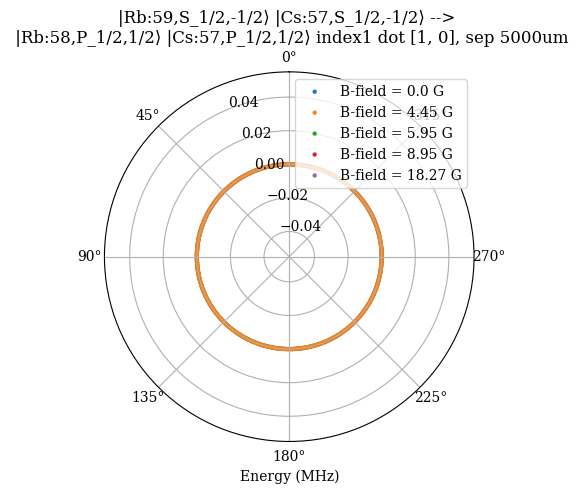

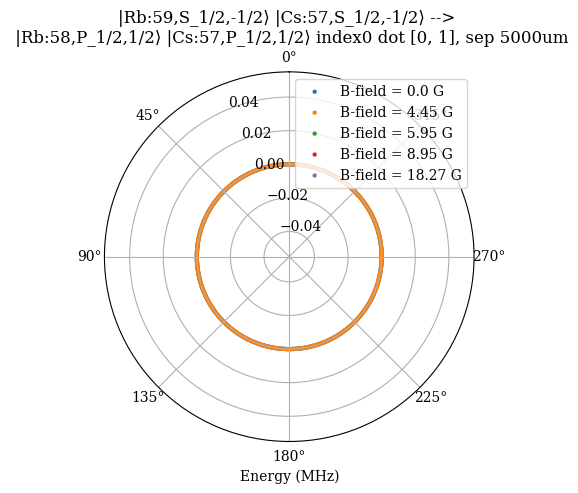

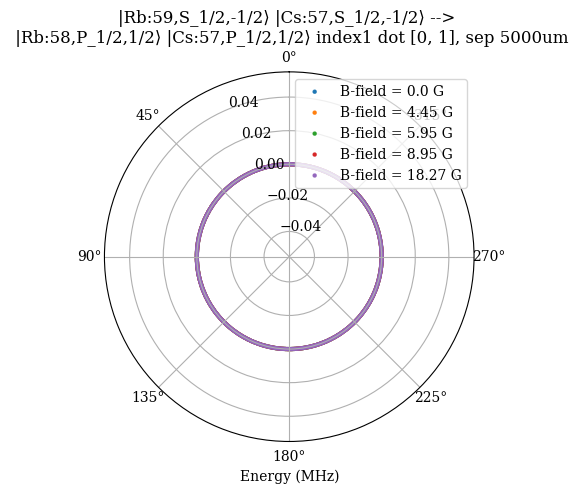

In [30]:
if not os.path.exists(figpath + 'eigenenergies dots\\'):
    os.makedirs(figpath + 'eigenenergies dots\\')
from matplotlib.colors import TABLEAU_COLORS
prop_cycle = plt.rcParams['axes.prop_cycle']
colours = prop_cycle.by_key()['color']


for r in rs:
    for tup in tups:
        for index in range(2):
            fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})
            # 
            ax.set_theta_zero_location("N")
            for i, b in enumerate(bs):

                # 1. Convert the base color name to RGB (e.g., 'red' -> [1, 0, 0])
                base_rgb = mcolors.to_rgb(colours[i])
                
                # 2. Build the RGBA array: (N, 4)
                # This stores the specific relevance for every point in THIS set
                rgba = np.zeros((len(Ediag[f'{r}{b}'][f'{index}']), 4))
                rgba[:, :3] = base_rgb
                rgba[:, 3] = overlap[f'{r}{b}'][f'{index}{tup}']
                
                ax.scatter(np.radians(thetas[f'{r}{b}']),
                        abs(np.array(Ediag[f'{r}{b}'][f'{index}'])),
                        c=rgba,
                        marker='.',
                        linewidths=.1,
                        label = fr'B-field = {str(np.round(b,2))} G')
                
            leg = plt.legend()
            for lh in leg.legend_handles:
                if lh is not None:  # Use 'is not None' instead of 'if lh:'
                    lh.set_alpha(1)
            ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} index{index} dot {tup}, sep {r}um')
            ax.set_xlabel(r"Energy (MHz)")
            plt.savefig(figpath + f'eigenenergies dots\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), sep {r}um, e {np.round(e,1)}Vcm evec {index} dot tup.png')

        plt.show()
        plt.close()

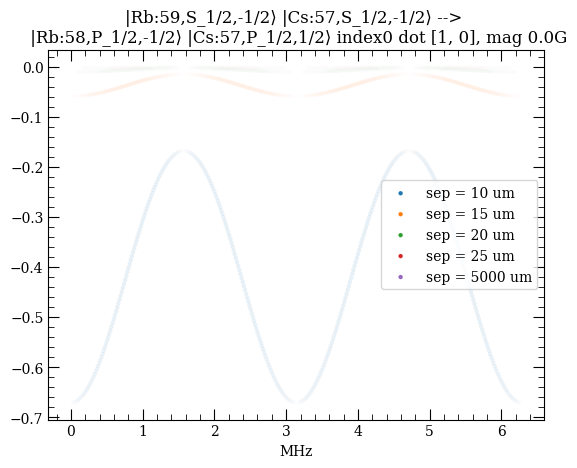

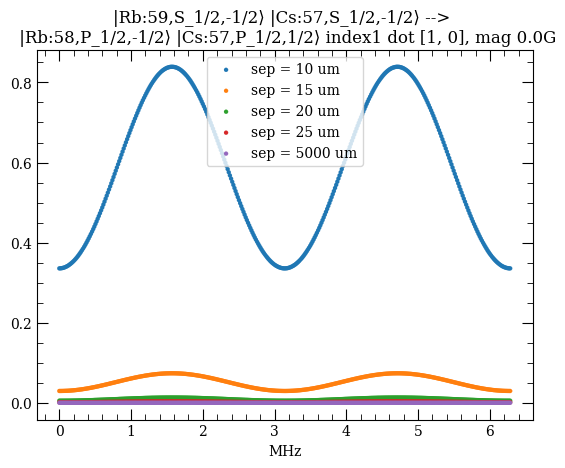

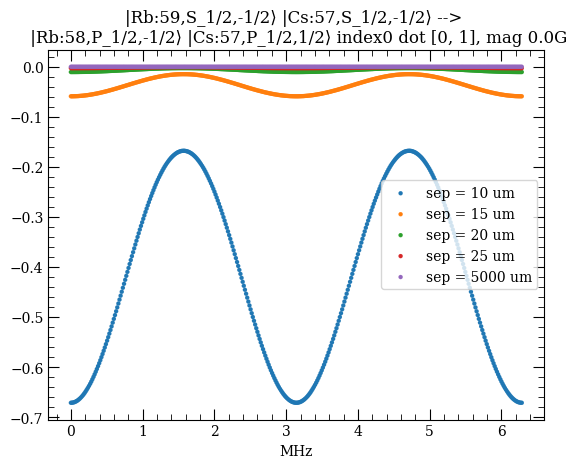

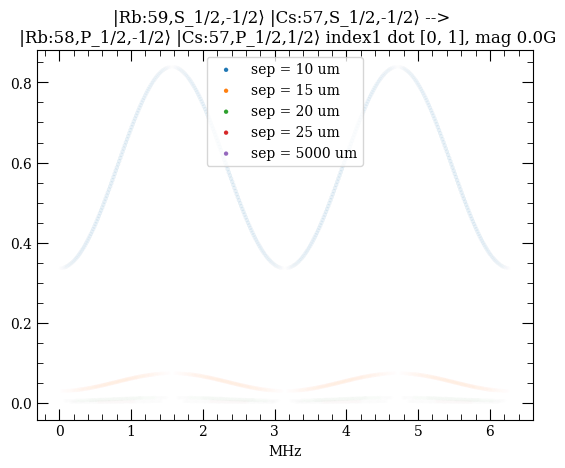

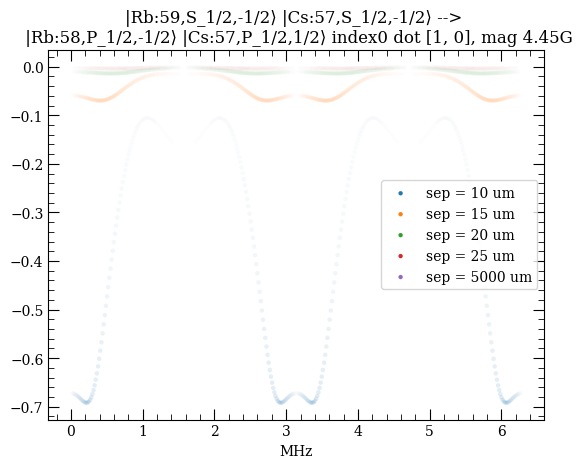

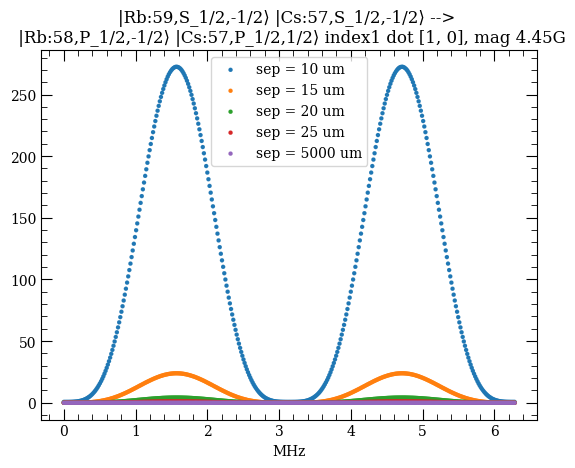

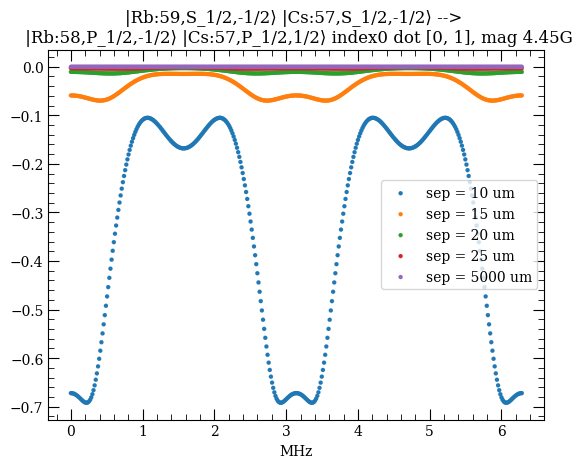

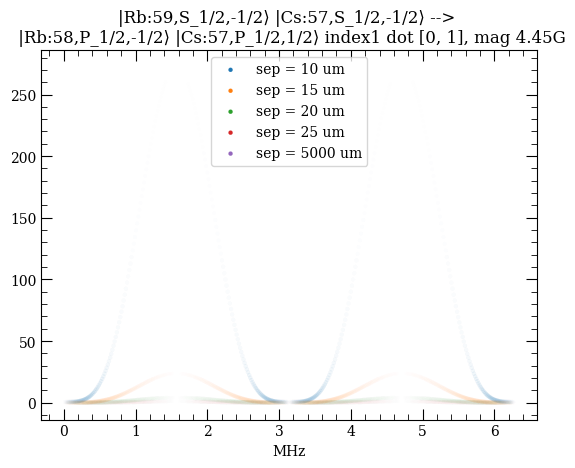

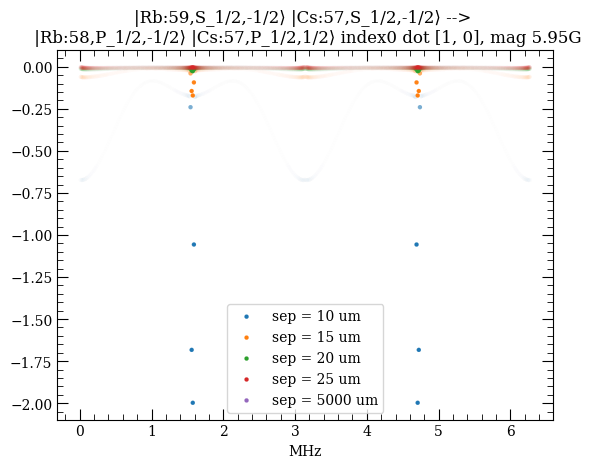

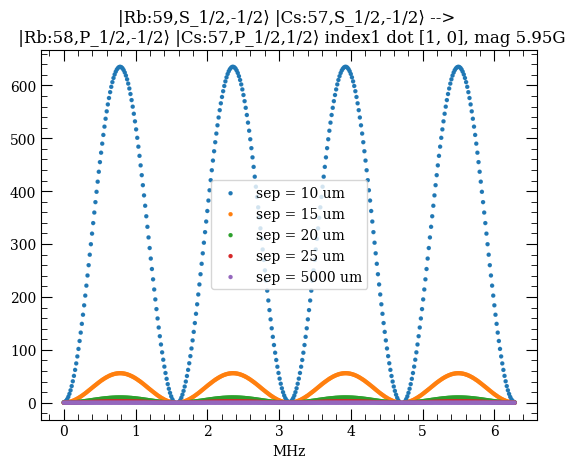

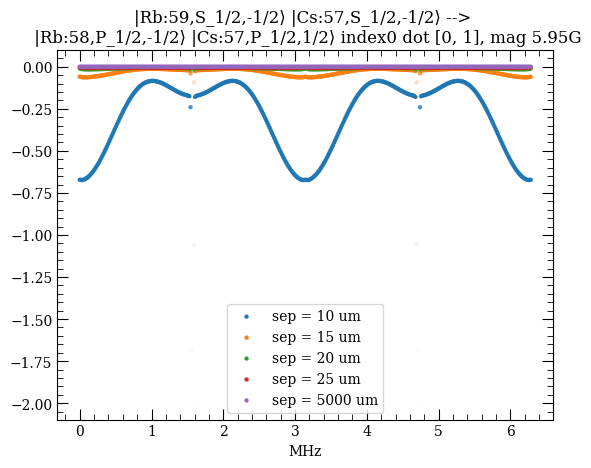

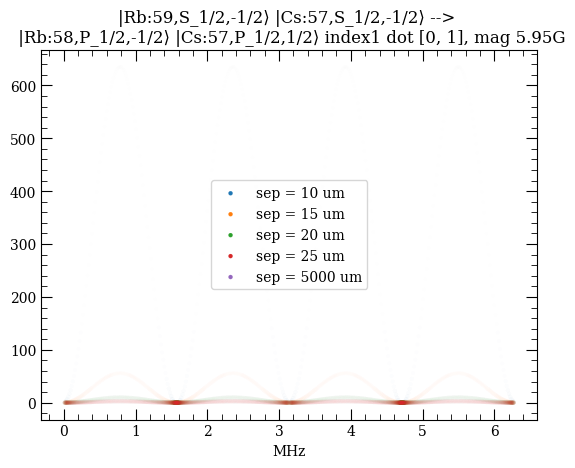

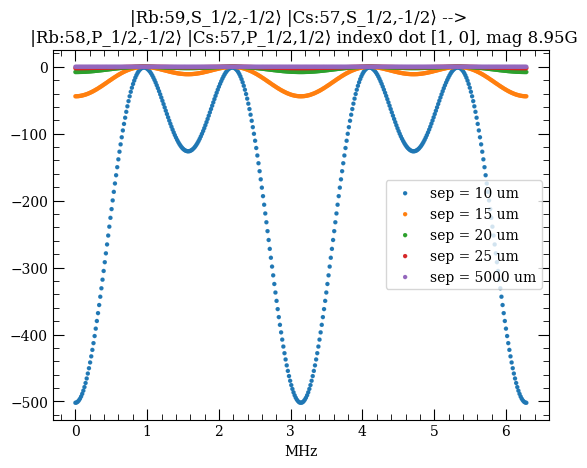

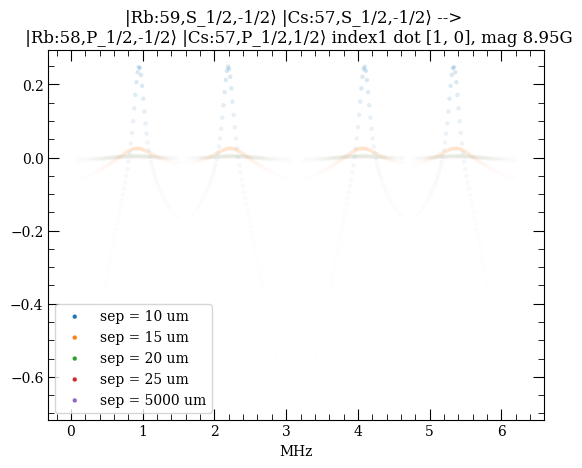

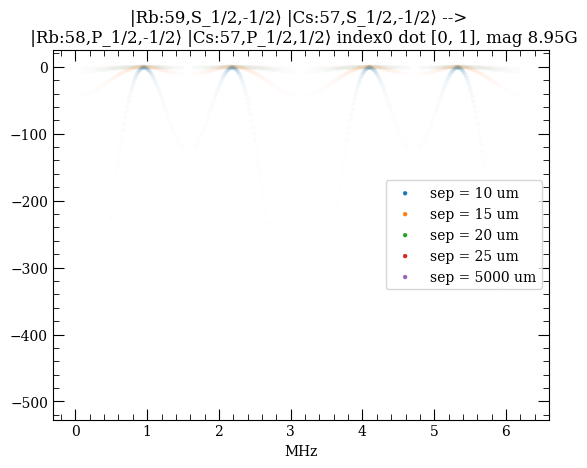

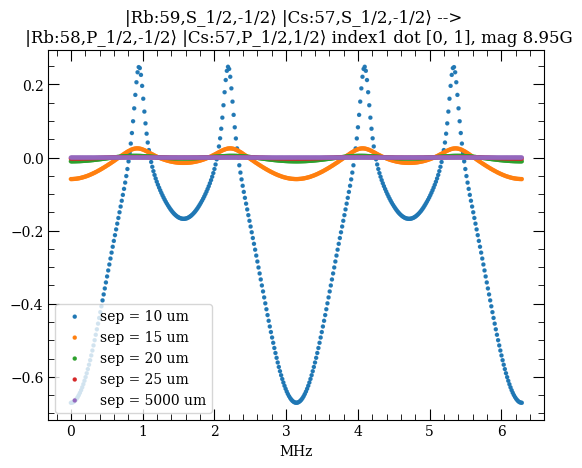

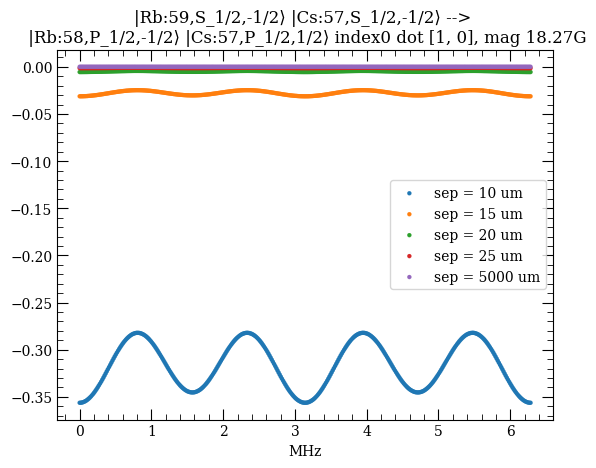

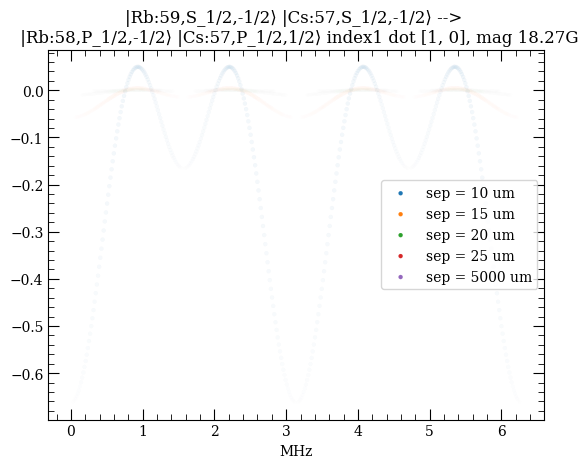

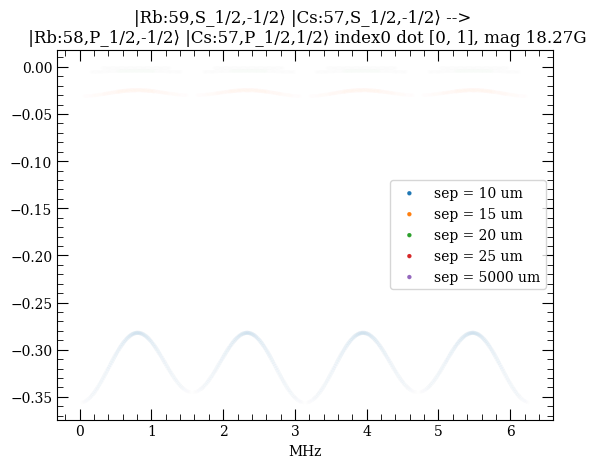

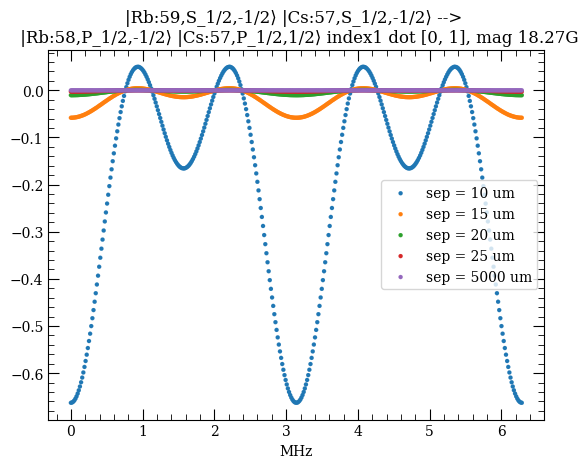

In [26]:
if not os.path.exists(figpath + 'eigenenergies dots\\'):
    os.makedirs(figpath + 'eigenenergies dots\\')
for b in bs:
    for tup in tups:
        for index in range(2):
            fig, ax = plt.subplots()
            # subplot_kw={'projection': 'polar'}
            # ax.set_theta_zero_location("N")
            for i, r in enumerate(rs[1:]):

                # 1. Convert the base color name to RGB (e.g., 'red' -> [1, 0, 0])
                base_rgb = mcolors.to_rgb(colours[i])
                
                # 2. Build the RGBA array: (N, 4)
                # This stores the specific relevance for every point in THIS set
                rgba = np.zeros((len(Ediag[f'{r}{b}'][f'{index}']), 4))
                rgba[:, :3] = base_rgb
                rgba[:, 3] = overlap[f'{r}{b}'][f'{index}{tup}']
                
                ax.scatter(np.radians(thetas[f'{r}{b}']),
                        np.array(Ediag[f'{r}{b}'][f'{index}']),
                        c=rgba,
                        marker='.',
                        linewidths=.1,
                        label = fr'sep = {str(np.round(r,2))} um')
                
            leg = plt.legend()
            for lh in leg.legend_handles:
                if lh is not None:  # Use 'is not None' instead of 'if lh:'
                    lh.set_alpha(1)
            ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} index{index} dot {tup}, mag {np.round(b,2)}G')
            ax.set_xlabel('MHz')
            plt.savefig(figpath + f'eigenenergies dots\\m0s({tuple0[0].m,tuple0[1].m}), m1s({tuple1[0].m,tuple1[1].m}), mag {np.round(b,3)}G, e {np.round(e,1)}Vcm evec {index} dot tup.png')

        plt.show()
        plt.close()

In [32]:
for i, ket in enumerate(ket_tuples):
    print(i, ket)

figpath = fr'C:\\Users\\tommy\\OneDrive - Durham University\\level 4 Project\\Figures\\interesting channels\\{atom1}{atom2}\\{n1_0}{orbs[l1_0]}{j1_0} {n2_0}{orbs[l2_0]}{j2_0}\\angular\\2x2 hams avg\\'
if not os.path.exists(figpath + 'overlaps\\'):
    os.makedirs(figpath + 'overlaps\\')
if not os.path.exists(figpath + 'energies\\'):
    os.makedirs(figpath + 'energies\\')

Ediags = {f'{mag}' : {
    'state0' : [abs(eval[0]) for eval in eval_list[f'{mag}']],
    'state1' : [abs(eval[1]) for eval in eval_list[f'{mag}']]
} for mag in bs}
print(Ediags)
tup0_overlaps0 = {f'{mag}' : [abs(np.dot([1,0], evec[0])) for evec in evec_list[f'{mag}']] for mag in bs}
tup1_overlaps1 = {f'{mag}' : [abs(np.dot([0,1], evec[1])) for evec in evec_list[f'{mag}']] for mag in bs}
tup0_overlaps1 = {f'{mag}' : [abs(np.dot([1,0], evec[1])) for evec in evec_list[f'{mag}']] for mag in bs}
tup1_overlaps0 = {f'{mag}' : [abs(np.dot([0,1], evec[0])) for evec in evec_list[f'{mag}']] for mag in bs}

print(tup1_overlaps1)

# state0 overlap with tuple 0
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(Thetas[f'{mag}']), tup0_overlaps0[f'{mag}'], label = f'{mag}G') 
ax.set_title('state0 overlap with tuple 0')
ax.set_xlabel(r"$\theta$ (degree)")
plt.savefig(figpath + f'overlaps\\mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} 0index0.png')
plt.show() 

# state1 overlap with tuple 0
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(Thetas[f'{mag}']), tup0_overlaps1[f'{mag}'], label = f'{mag}G')
# plt.legend()
ax.set_title('state1 overlap with tuple 0')
ax.set_xlabel(r"$\theta$ (degree)")
plt.savefig(figpath + f'overlaps\\mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} 0index1.png')
plt.show()    

# state0 overlap with tuple 1
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(Thetas[f'{mag}']), tup1_overlaps0[f'{mag}'], label = f'{mag}G')
# plt.legend()
ax.set_title('state0 overlap with tuple 1')
ax.set_xlabel(r"$\theta$ (degree)")
plt.savefig(figpath + f'overlaps\\mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} 1index0.png')
plt.show()  

# state1 overlap with tuple 1
ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(Thetas[f'{mag}']), tup1_overlaps1[f'{mag}'], label = f'{mag}G')
# plt.legend()
ax.set_title('state1 overlap with tuple 1')
ax.set_xlabel(r"$\theta$ (degree)")
plt.savefig(figpath + f'overlaps\\mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} 1index1.png')
plt.show()



ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:
    ax.plot(np.radians(thetaList), np.array(Ediags[f'{mag}']['state0']), "-", label= f'state0 {round(mag, 2)}G')
plt.legend()
ax.set_xlabel(r"$\theta$ (degree)")
ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} ({energy_unit})')
plt.savefig(figpath + f'\\energies\\mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} index0.png')
plt.show()


ax = plt.subplot(111, projection="polar")
ax.set_theta_zero_location("N")
for mag in bs:   
    ax.plot(np.radians(thetaList), np.array(Ediags[f'{mag}']['state1']), "-", label= f'state1 {round(mag, 2)}G')
    # ax.plot(np.radians(thetaList), J00[f'{mag}'], "-", label = f'off diag {mag}G')
plt.legend()
ax.set_xlabel(r"$\theta$ (degree)")
ax.set_title(f'{tuple0[0]} {tuple0[1]} --> \n {tuple1[0]} {tuple1[1]} ({energy_unit})')

plt.savefig(figpath + f'\\energies\\mjs({tuple0[0].m},{tuple0[1].m}) to mjs({tuple1[0].m}, {tuple1[1].m}), sep {r} index1.png')
plt.show()

0 (KetAtom(Rb:59,S_1/2,-1/2), KetAtom(Cs:57,S_1/2,-1/2))
1 (KetAtom(Rb:58,P_1/2,1/2), KetAtom(Cs:57,P_1/2,1/2))


KeyError: '0.0'